In [26]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Carregar os dados do arquivo JSONL
wines = []
with open('../data/interim/wines_all.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        wines.append(json.loads(line))

print(f"Total de vinhos carregados: {len(wines)}\n")

# ---- INÍCIO DA EXIBIÇÃO DO 1º VINHO ----
primeiro_vinho = wines[0].copy()

# Removendo os 'reviews' apenas da exibição para não travar a tela
primeiro_vinho.pop('reviews', None)
if 'wine' in primeiro_vinho and isinstance(primeiro_vinho['wine'], dict):
    primeiro_vinho['wine'].pop('reviews', None)

print("--- DADOS DO 1º VINHO (sem os reviews) ---")
print(json.dumps(primeiro_vinho, indent=2, ensure_ascii=False))
print("-" * 50 + "\n")
# ---- FIM DA EXIBIÇÃO ----

# Converter para DataFrame
df = pd.DataFrame(wines)
df.head(2)


Total de vinhos carregados: 1688

--- DADOS DO 1º VINHO (sem os reviews) ---
{
  "id": 7553878,
  "name": "La Marchigiana Bonarda",
  "seo_name": "la-marchigiana-bonarda",
  "type_id": 1,
  "vintage_type": 0,
  "is_natural": false,
  "region": {
    "id": 454,
    "name": "Mendoza",
    "name_en": "",
    "seo_name": "mendoza",
    "country": {
      "code": "ar",
      "name": "Argentina",
      "native_name": "Argentina",
      "seo_name": "argentina",
      "currency": {
        "code": "ARS",
        "name": "Peso argentino",
        "prefix": "$",
        "suffix": null
      },
      "regions_count": 41,
      "users_count": 689898,
      "wines_count": 38347,
      "wineries_count": 5484,
      "most_used_grapes": [
        {
          "id": 9,
          "name": "Malbec",
          "seo_name": "malbec",
          "has_detailed_info": true,
          "wines_count": 219735,
          "parent_grape_id": null
        },
        {
          "id": 2,
          "name": "Cabernet Sauvig

,id,name,seo_name,type_id,vintage_type,is_natural,region,winery,taste,statistics,style,has_valid_ratings,reviews
0,7553878,La Marchigiana Bonarda,la-marchigiana-bonarda,1,0,False,"{'id': 454, 'name': 'Mendoza', 'name_en': '', ...","{'id': 253780, 'name': 'Bodegas y Viñedos Nico...","{'structure': {'acidity': 4.266384, 'fizziness...",None,"{'id': 10, 'seo_name': 'argentinian-bonarda', ...",False,"[{'id': 253163888, 'rating': 4.3, 'note': 'Bri..."
1,5946579,El Padre,el-padre,1,0,False,"{'id': 721, 'name': 'Vale do Maipo', 'name_en'...","{'id': 227920, 'name': 'Morande Adventure', 's...","{'structure': None, 'flavor': [{'group': 'oak'...",None,None,False,"[{'id': 171305186, 'rating': 4.0, 'note': 'Bom..."


In [27]:
# Célula: Cobertura de Campos

total_wines = len(wines)
has_taste_structure = 0
has_style_food = 0
has_reviews = 0

for item in wines:
    wine = item.get('wine', item) # Pode estar aninhado
    
    # Checar taste.structure
    if wine.get('taste') and isinstance(wine['taste'], dict) and wine['taste'].get('structure'):
        has_taste_structure += 1
        
    # Checar style.food
    if wine.get('style') and isinstance(wine['style'], dict) and wine['style'].get('food'):
        has_style_food += 1
        
    # Checar reviews (às vezes no item raiz, às vezes dentro de wine)
    if item.get('reviews') and len(item['reviews']) > 0:
        has_reviews += 1
    elif wine.get('reviews') and len(wine['reviews']) > 0:
        has_reviews += 1

print(f"--- 1. Cobertura de Campos (Total: {total_wines} vinhos) ---")
print(f"taste.structure : {has_taste_structure} ({(has_taste_structure/total_wines)*100:.1f}%)")
print(f"style.food      : {has_style_food} ({(has_style_food/total_wines)*100:.1f}%)")
print(f"reviews         : {has_reviews} ({(has_reviews/total_wines)*100:.1f}%)")


--- 1. Cobertura de Campos (Total: 1688 vinhos) ---
taste.structure : 1558 (92.3%)
style.food      : 1552 (91.9%)
reviews         : 1682 (99.6%)


In [28]:
from collections import Counter

type_ids = Counter()
food_names = Counter()
flavor_groups = Counter()
countries = Counter()
regions = Counter()
wineries = Counter()

for item in wines:
    wine = item.get('wine', item)
    
    if wine.get('type_id'):
        type_ids[wine['type_id']] += 1
        
    if wine.get('style') and isinstance(wine['style'], dict) and wine['style'].get('food'):
        for food in wine['style']['food']:
            food_names[food.get('name')] += 1
            
    if wine.get('taste') and isinstance(wine['taste'], dict) and wine['taste'].get('flavor'):
        for flavor in wine['taste']['flavor']:
            flavor_groups[flavor.get('group')] += 1
            
    if wine.get('region') and isinstance(wine['region'], dict):
        regions[wine['region'].get('name')] += 1
        if wine['region'].get('country'):
            countries[wine['region']['country'].get('name')] += 1
            
    if wine.get('winery') and isinstance(wine['winery'], dict):
        wineries[wine['winery'].get('name')] += 1

print("--- 2. Valores Únicos (COMPLETO) ---")
print(f"\n🍷 Tipos de Vinho (type_id):")
for t_id, qtd in type_ids.most_common():
    print(f"  Type {t_id}: {qtd} ocorrências")

print(f"\n🍽️ Todas as Comidas (style.food) - {len(food_names)} categorias únicas:")
for food, qtd in food_names.most_common():
    print(f"  {food}: {qtd}")

print(f"\n👅 Todos os Grupos de Sabor (flavor groups) - {len(flavor_groups)} grupos únicos:")
for group, qtd in flavor_groups.most_common():
    print(f"  {group}: {qtd}")

print(f"\n🌍 Todos os Países - {len(countries)} países únicos:")
for country, qtd in countries.most_common():
    print(f"  {country}: {qtd}")

print(f"\n🗺️ Top 20 Regiões (Total de {len(regions)} regiões únicas cadastradas):")
for reg, qtd in regions.most_common(20):
    print(f"  {reg}: {qtd}")

print(f"\n🍇 Top 20 Vinícolas (Total de {len(wineries)} vinícolas únicas cadastradas):")
for win, qtd in wineries.most_common(20):
    print(f"  {win}: {qtd}")


--- 2. Valores Únicos (COMPLETO) ---

🍷 Tipos de Vinho (type_id):
  Type 1: 1284 ocorrências
  Type 2: 264 ocorrências
  Type 3: 51 ocorrências
  Type 24: 44 ocorrências
  Type 4: 34 ocorrências
  Type 7: 11 ocorrências

🍽️ Todas as Comidas (style.food) - 23 categorias únicas:
  Carne de vaca: 1136
  Cordeiro: 931
  Aves: 866
  Carne de caça (cervo, veado): 642
  Massa: 454
  Vitela: 383
  Carne de porco: 291
  Marisco: 241
  Carne curada: 167
  Peixe (salmão, atum etc.): 156
  Vegetariano: 155
  Peixes magros: 90
  Queijos suaves e moles: 90
  Queijos maduros: 82
  Aperitivos e lanches: 82
  Queijo azul: 73
  Queijo de cabra: 47
  Comida picante: 38
  Sobremesa: 35
  Cogumelos: 25
  Aperitivo: 23
  Sobremesas com frutas: 5
  Qualquer junk food serve: 1

👅 Todos os Grupos de Sabor (flavor groups) - 13 grupos únicos:
  oak: 1531
  earth: 1517
  non_oak: 1500
  spices: 1482
  microbio: 1394
  red_fruit: 1388
  black_fruit: 1379
  floral: 1273
  vegetal: 1268
  dried_fruit: 1224
  citrus_

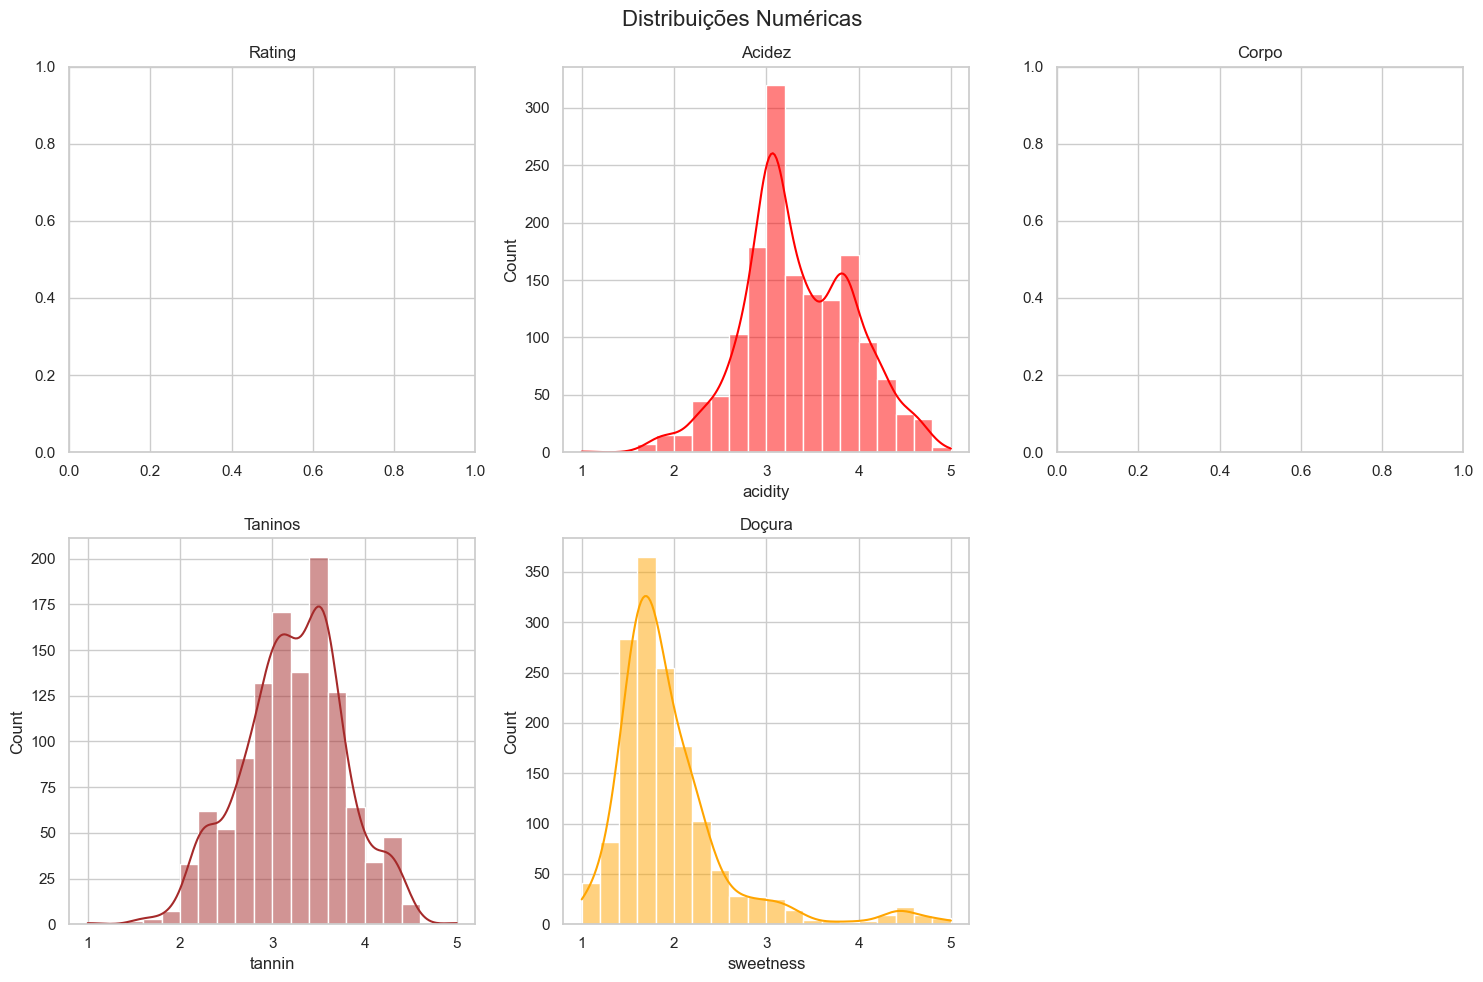

--- 3. Estatísticas Básicas (Média, Min, Max) ---
       acidity   tannin  sweetness
count  1558.00  1178.00    1507.00
mean      3.35     3.23       1.95
std       0.60     0.56       0.63
min       1.00     1.00       1.00
25%       2.99     2.88       1.59
50%       3.25     3.24       1.79
75%       3.81     3.59       2.13
max       5.00     5.00       5.00


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numeric_data = []
for item in wines:
    wine = item.get('wine', item)
    
    rating = None
    if wine.get('statistics') and isinstance(wine['statistics'], dict):
        rating = wine['statistics'].get('ratings_average')
    elif item.get('statistics') and isinstance(item['statistics'], dict):
        rating = item['statistics'].get('ratings_average')
        
    acidity = body = tannin = sweetness = None
    if wine.get('taste') and isinstance(wine['taste'], dict) and wine['taste'].get('structure'):
        struct = wine['taste']['structure']
        if isinstance(struct, dict):
            acidity = struct.get('acidity')
            body = struct.get('body')
            tannin = struct.get('tannin')
            sweetness = struct.get('sweetness')
        
    numeric_data.append({
        'rating': rating,
        'acidity': acidity,
        'body': body,
        'tannin': tannin,
        'sweetness': sweetness
    })

df_num = pd.DataFrame(numeric_data)

# Plotando os gráficos
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Distribuições Numéricas", fontsize=16)

sns.histplot(df_num['rating'].dropna(), bins=20, ax=axes[0, 0], color='blue', kde=True).set_title('Rating')
sns.histplot(df_num['acidity'].dropna(), bins=20, ax=axes[0, 1], color='red', kde=True).set_title('Acidez')
sns.histplot(df_num['body'].dropna(), bins=20, ax=axes[0, 2], color='purple', kde=True).set_title('Corpo')
sns.histplot(df_num['tannin'].dropna(), bins=20, ax=axes[1, 0], color='brown', kde=True).set_title('Taninos')
sns.histplot(df_num['sweetness'].dropna(), bins=20, ax=axes[1, 1], color='orange', kde=True).set_title('Doçura')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

print("--- 3. Estatísticas Básicas (Média, Min, Max) ---")
print(df_num.describe().round(2))


--- Correção: Body e Rating ---
Vinhos com style.body: 1558 (92.3%)
Vinhos com taste.structure.intensity: 1558 (92.3%)
Vinhos com has_valid_ratings=True: 0 (0.0%)
Vinhos com rating numérico: 0 (0.0%)


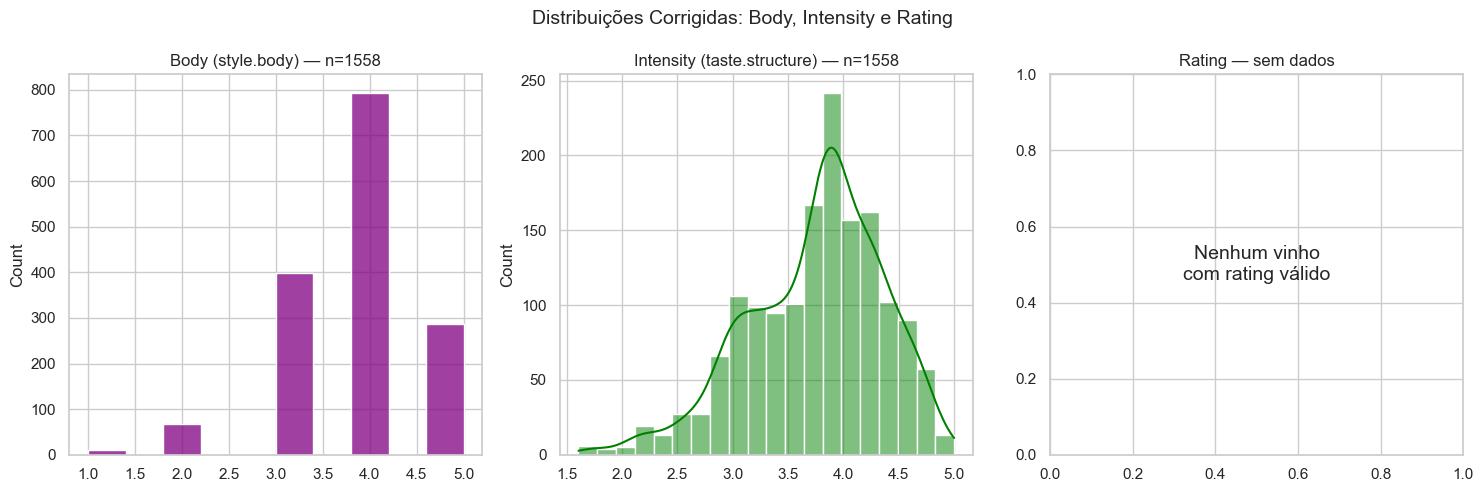


Body: valores únicos = [1, 2, 3, 4, 5]


In [30]:
# Corrigindo a extração de body e rating
body_vals = []
rating_vals = []
has_valid_ratings_count = 0
intensity_vals = []

for item in wines:
    # Body está em style.body
    if item.get('style') and isinstance(item['style'], dict) and item['style'].get('body') is not None:
        body_vals.append(item['style']['body'])
    
    # Intensity está em taste.structure.intensity
    if item.get('taste') and isinstance(item['taste'], dict) and item['taste'].get('structure'):
        struct = item['taste']['structure']
        if isinstance(struct, dict) and struct.get('intensity') is not None:
            intensity_vals.append(struct['intensity'])
    
    # Rating está em statistics.ratings_average (só quando has_valid_ratings é True)
    if item.get('has_valid_ratings') == True:
        has_valid_ratings_count += 1
        if item.get('statistics') and isinstance(item['statistics'], dict):
            avg = item['statistics'].get('ratings_average')
            if avg is not None:
                rating_vals.append(avg)

total = len(wines)
print(f"--- Correção: Body e Rating ---")
print(f"Vinhos com style.body: {len(body_vals)} ({len(body_vals)/total*100:.1f}%)")
print(f"Vinhos com taste.structure.intensity: {len(intensity_vals)} ({len(intensity_vals)/total*100:.1f}%)")
print(f"Vinhos com has_valid_ratings=True: {has_valid_ratings_count} ({has_valid_ratings_count/total*100:.1f}%)")
print(f"Vinhos com rating numérico: {len(rating_vals)} ({len(rating_vals)/total*100:.1f}%)")

# Histogramas corrigidos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribuições Corrigidas: Body, Intensity e Rating", fontsize=14)

sns.histplot(body_vals, bins=10, ax=axes[0], color='purple', kde=False)
axes[0].set_title(f'Body (style.body) — n={len(body_vals)}')

sns.histplot(intensity_vals, bins=20, ax=axes[1], color='green', kde=True)
axes[1].set_title(f'Intensity (taste.structure) — n={len(intensity_vals)}')

if rating_vals:
    sns.histplot(rating_vals, bins=20, ax=axes[2], color='blue', kde=True)
    axes[2].set_title(f'Rating — n={len(rating_vals)}')
    print(f"\nRating: média={sum(rating_vals)/len(rating_vals):.2f}, min={min(rating_vals):.2f}, max={max(rating_vals):.2f}")
else:
    axes[2].text(0.5, 0.5, 'Nenhum vinho\ncom rating válido', ha='center', va='center', fontsize=14)
    axes[2].set_title('Rating — sem dados')

plt.tight_layout()
plt.show()

print(f"\nBody: valores únicos = {sorted(set(body_vals))}")


In [31]:
print("--- 4. Nulos e Outliers ---")
null_counts = df_num.isnull().sum()

print("\nValores Vazios (Nulos) por Campo Numérico:")
print(null_counts)

print(f"\nPorcentagem de Vazios (%):")
print((null_counts / len(df_num) * 100).round(1))

# Checagem específica: Tintos sem tanino
tintos_sem_tanino = 0
total_tintos = 0

for item in wines:
    wine = item.get('wine', item)
    if wine.get('type_id') == 1:
        total_tintos += 1
        
        has_tannin = False
        if wine.get('taste') and isinstance(wine['taste'], dict) and wine['taste'].get('structure'):
            struct = wine['taste']['structure']
            if isinstance(struct, dict) and struct.get('tannin') is not None:
                has_tannin = True
                
        if not has_tannin:
            tintos_sem_tanino += 1

print(f"\n--- Análise de Consistência (Taninos) ---")
print(f"Total de vinhos tintos analisados: {total_tintos}")
print(f"Tintos que vieram COM tanino nulo/vazio: {tintos_sem_tanino} ({(tintos_sem_tanino/total_tintos)*100 if total_tintos > 0 else 0:.1f}%)")


--- 4. Nulos e Outliers ---

Valores Vazios (Nulos) por Campo Numérico:
rating       1688
acidity       130
body         1688
tannin        510
sweetness     181
dtype: int64

Porcentagem de Vazios (%):
rating       100.0
acidity        7.7
body         100.0
tannin        30.2
sweetness     10.7
dtype: float64

--- Análise de Consistência (Taninos) ---
Total de vinhos tintos analisados: 1284
Tintos que vieram COM tanino nulo/vazio: 106 (8.3%)


--- Rating via Reviews ---
Vinhos que possuem pelo menos 1 review com rating: 1682 (99.6%)
Total de reviews com rating no dataset: 5039
Rating médio (todos os reviews): 4.26
Min: 1.0, Max: 5.0


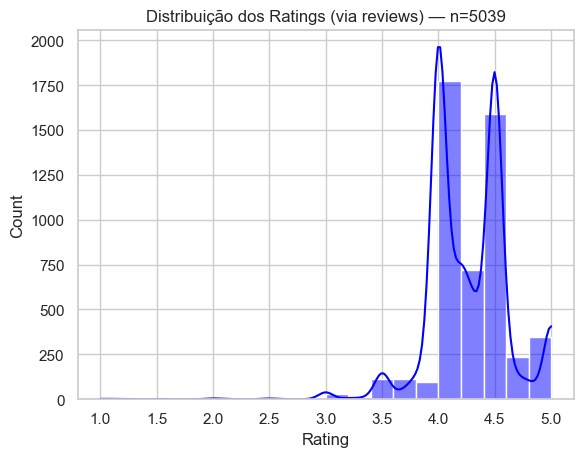

In [32]:
# Verificar ratings dentro dos reviews individuais
vinhos_com_reviews_rated = 0
all_review_ratings = []

for item in wines:
    reviews = item.get('reviews', [])
    ratings_deste_vinho = []
    for r in reviews:
        if r.get('rating') is not None:
            ratings_deste_vinho.append(r['rating'])
            all_review_ratings.append(r['rating'])
    if ratings_deste_vinho:
        vinhos_com_reviews_rated += 1

total = len(wines)
print(f"--- Rating via Reviews ---")
print(f"Vinhos que possuem pelo menos 1 review com rating: {vinhos_com_reviews_rated} ({vinhos_com_reviews_rated/total*100:.1f}%)")
print(f"Total de reviews com rating no dataset: {len(all_review_ratings)}")

if all_review_ratings:
    import statistics
    print(f"Rating médio (todos os reviews): {statistics.mean(all_review_ratings):.2f}")
    print(f"Min: {min(all_review_ratings):.1f}, Max: {max(all_review_ratings):.1f}")
    
    sns.histplot(all_review_ratings, bins=20, color='blue', kde=True)
    plt.title(f'Distribuição dos Ratings (via reviews) — n={len(all_review_ratings)}')
    plt.xlabel('Rating')
    plt.show()


In [33]:
total = len(wines)
com_food = 0
sem_food = 0

for item in wines:
    if item.get('style') and isinstance(item['style'], dict) and item['style'].get('food') and len(item['style']['food']) > 0:
        com_food += 1
    else:
        sem_food += 1

print(f"--- 5. Cobertura de style.food ---")
print(f"Com food labels: {com_food} ({com_food/total*100:.1f}%)")
print(f"Sem food labels: {sem_food} ({sem_food/total*100:.1f}%)")


--- 5. Cobertura de style.food ---
Com food labels: 1552 (91.9%)
Sem food labels: 136 (8.1%)


In [38]:
from collections import defaultdict, Counter

keywords_por_grupo = defaultdict(Counter)

for item in wines:
    if item.get('taste') and isinstance(item['taste'], dict) and item['taste'].get('flavor'):
        for flavor in item['taste']['flavor']:
            grupo = flavor.get('group', 'desconhecido')
            if flavor.get('primary_keywords'):
                for kw in flavor['primary_keywords']:
                    keywords_por_grupo[grupo][kw['name']] += kw.get('count', 1)

print(f"--- 6. Flavor Keywords por Grupo (TODAS) ---\n")
for grupo in sorted(keywords_por_grupo.keys()):
    kws = keywords_por_grupo[grupo]
    print(f"🔹 {grupo} ({len(kws)} keywords únicas):")
    for kw, qtd in kws.most_common():
        print(f"    {kw}: {qtd}")
    print()


--- 6. Flavor Keywords por Grupo (TODAS) ---

🔹 black_fruit (34 keywords únicas):
    amora: 92362
    ameixa: 83265
    fruta preta: 43202
    groselha: 38664
    frutas escuras: 34998
    cassis: 28020
    cereja preta: 27552
    mirtilo: 23810
    geleia: 9067
    ameixa preta: 5086
    espinheiro: 2987
    azeitona preta: 1742
    amora madura: 1670
    amoreira: 1580
    boysenberry: 1180
    geleia de amora: 1167
    framboesa preta: 975
    geleia de frutas: 414
    geleia de groselha: 365
    ameixa com especiarias: 224
    boldo: 212
    ameixa azeda: 202
    tapenade de azeitona: 165
    molho de ameixa: 142
    hoisin: 84
    ameixa tostada: 77
    açaí: 63
    geleia de uva: 61
    mirtilo silvestre: 52
    azeitona de kalamata: 48
    molho de frutas: 45
    ameixa doce: 25
    molho de amora: 15
    marionberry: 14

🔹 citrus_fruit (24 keywords únicas):
    citrino: 33008
    limão: 15935
    toranja: 7684
    lima: 5837
    laranja: 4904
    casca de laranja: 2088
    ras

In [36]:
import sys, os

jsonl_path = '../data/interim/wines_all.jsonl'
file_size_mb = os.path.getsize(jsonl_path) / (1024 * 1024)
mem_size_mb = sys.getsizeof(wines) / (1024 * 1024)

print(f"--- 7. Tamanho e Dimensionalidade ---")
print(f"Arquivo JSONL em disco: {file_size_mb:.2f} MB")
print(f"Lista wines na memória (shallow): {mem_size_mb:.2f} MB")
print(f"Total de vinhos: {len(wines)}")
print(f"Chaves no 1º nível: {list(wines[0].keys())}")
print(f"Total de reviews no dataset: {sum(len(w.get('reviews', [])) for w in wines)}")



--- 7. Tamanho e Dimensionalidade ---
Arquivo JSONL em disco: 36.99 MB
Lista wines na memória (shallow): 0.01 MB
Total de vinhos: 1688
Chaves no 1º nível: ['id', 'name', 'seo_name', 'type_id', 'vintage_type', 'is_natural', 'region', 'winery', 'taste', 'statistics', 'style', 'has_valid_ratings', 'reviews']
Total de reviews no dataset: 5039
